# DemoGorgN — Icechunk Visualization Pipeline

End-to-end notebook that:
1. Connects to the public Icechunk archive (EPSG:3031, 500 m, 100 realizations)
2. Selects a single realization as the 2-D input for the pyramid
3. Generates a multiscale overview pyramid with **ndpyramid**
4. Stores the pyramid in a local **Icechunk** store (production: push to S3)
5. Serves tiles dynamically via **TiTiler-XArray** (optional local server)
6. Visualizes interactively via **ipyleaflet** (ImageOverlay) and **ipywidgets** (level browser)

### CRS note
The source data is in **EPSG:3031** (Antarctic Polar Stereographic). Web slippy-map tiles use
EPSG:3857 (Web Mercator), which cannot represent latitudes beyond ±85°. For Antarctica the
cleanest workarounds are:
- **ImageOverlay** (this notebook): reproject bounding corners to WGS-84, overlay a raster image.
- **TiTiler + rio-tiler**: on-the-fly reprojection to 3857 at request time (works, with some polar distortion).
- **deck.gl with `OrthographicView`** or a `proj4leaflet` custom CRS (ideal for production).

## 0 — Dependencies
The project uses **uv**. Run this cell once to add the new packages.

In [16]:
import subprocess, sys

EXTRA_PACKAGES = [
    "ndpyramid",
    "rioxarray",
    "pyproj",
    "ipyleaflet",
    "ipywidgets",
]

TITILER_PACKAGES = [
    "titiler-xarray",
    "uvicorn[standard]",
]

def uv_add(pkgs):
    result = subprocess.run(
        ["uv", "add"] + pkgs,
        capture_output=True, text=True
    )
    print(result.stdout or result.stderr)

print("Adding core visualization packages...")
uv_add(EXTRA_PACKAGES)

print("\nAdding TiTiler (optional — needed for dynamic tile serving)...")
uv_add(TITILER_PACKAGES)

Adding core visualization packages...
Resolved 223 packages in 7ms
Audited 151 packages in 0.23ms


Adding TiTiler (optional — needed for dynamic tile serving)...
Resolved 223 packages in 0.43ms
Audited 151 packages in 0.07ms



## 1 — Imports

In [17]:
import os
import io
import base64
import shutil
import warnings
import threading
import time

import numpy as np
import xarray as xr
import zarr
import icechunk
import rioxarray  # noqa — registers .rio accessor on xarray
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import ipywidgets as widgets
from IPython.display import display
from pyproj import Transformer
from ipyleaflet import Map, ImageOverlay, TileLayer, basemaps, LayersControl, ScaleControl, projections

warnings.filterwarnings("ignore")
print(f"xarray  {xr.__version__}")
print(f"zarr    {zarr.__version__}")
print(f"icechunk {icechunk.__version__}")

xarray  2026.4.0
zarr    3.1.6
icechunk 2.0.2


## 2 — Connect to the Icechunk archive (public, no credentials)

In [18]:
REALIZATIONS_STORAGE = icechunk.local_filesystem_storage("data/realizations.icechunk")

repo = icechunk.Repository.open(REALIZATIONS_STORAGE)
session = repo.readonly_session("main")

ds = xr.open_zarr(session.store, consolidated=False, zarr_format=3)
print(ds)

  2026-04-24T21:42:01.922461Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

<xarray.Dataset> Size: 71GB
Dimensions:       (seed_id: 100, y: 13334, x: 13334)
Coordinates:
  * seed_id       (seed_id) int64 800B 0 1 2 3 4 5 6 7 ... 93 94 95 96 97 98 99
  * y             (y) float32 53kB 3.333e+06 3.333e+06 ... -3.333e+06 -3.333e+06
  * x             (x) float32 53kB -3.333e+06 -3.333e+06 ... 3.333e+06 3.333e+06
Data variables:
    realizations  (seed_id, y, x) float32 71GB dask.array<chunksize=(100, 128, 128), meta=np.ndarray>


In [19]:
# Spatial metadata
x = ds["x"].values
y = ds["y"].values
res_m = abs(float(x[1] - x[0]))

print(f"Variable     : {list(ds.data_vars)}")
print(f"Realizations : {ds.dims['seed_id']}")
print(f"Grid         : {ds.dims['y']} × {ds.dims['x']} pixels")
print(f"Resolution   : {res_m:.0f} m")
print(f"x range      : [{x.min():.0f}, {x.max():.0f}] m  (EPSG:3031)")
print(f"y range      : [{y.min():.0f}, {y.max():.0f}] m  (EPSG:3031)")
print(f"dtype        : {ds['realizations'].dtype}")
print(f"Chunk shape  : {ds['realizations'].encoding.get('chunks', 'unknown')}")

Variable     : ['realizations']
Realizations : 100
Grid         : 13334 × 13334 pixels
Resolution   : 500 m
x range      : [-3333250, 3333250] m  (EPSG:3031)
y range      : [-3333250, 3333250] m  (EPSG:3031)
dtype        : float32
Chunk shape  : (100, 128, 128)


## 3 — Select a single realization

The pyramid requires 2-D input. We pick one realization by `seed_id` index — a single
`(y, x)` slice of ~700 MB. Change `REALIZATION_INDEX` to visualize a different member.

In [20]:
REALIZATION_INDEX = 0  # change to any value in 0–99

# drop_encoding() strips the 3D chunk spec (100, 512, 512) carried over from
# the source store — otherwise to_zarr() rejects the mismatched encoding
da = ds["realizations"].isel(seed_id=REALIZATION_INDEX).drop_encoding()

ds_2d = xr.Dataset({"bed_elevation": da})
ds_2d = ds_2d.rio.write_crs("EPSG:3031")

print(f"Realization : seed_id={int(ds['seed_id'].values[REALIZATION_INDEX])}")
print(f"Shape       : {da.shape}")
print(f"dtype       : {da.dtype}")
print(f"Memory      : {da.nbytes / 1e9:.2f} GB (uncompressed)")

Realization : seed_id=0
Shape       : (13334, 13334)
dtype       : float32
Memory      : 0.71 GB (uncompressed)


## 4 — Generate multiscale pyramid with ndpyramid

`pyramid_coarsen` produces an `xarray.DataTree` where:
- node `"0"` = native resolution
- node `"1"` = 2× coarser, node `"2"` = 4× coarser, …

Each level halves the pixel count in both spatial dimensions. The computation is **lazy**
(backed by the remote zarr store) — actual I/O happens when we write to disk.

In [21]:
from ndpyramid import pyramid_coarsen

# 5 halvings: native → 2× → 4× → 8× → 16× → 32×
COARSEN_FACTORS = [2, 2, 2, 2, 2]

print("Pyramid levels (approx):")
ny, nx = ds_2d.dims["y"], ds_2d.dims["x"]
factor_cumulative = 1
print(f"  Level 0 (native)  : {ny} x {nx}  at {int(res_m * factor_cumulative)} m")
for lvl, f in enumerate(COARSEN_FACTORS, start=1):
    factor_cumulative *= f
    print(f"  Level {lvl} (/{factor_cumulative:>2}×)     : {ny // factor_cumulative} × {nx // factor_cumulative}  at {int(res_m * factor_cumulative)} m")

print("\nBuilding pyramid (lazy — no data loaded yet)...")
pyramid = pyramid_coarsen(
    ds_2d,
    factors=COARSEN_FACTORS,
    dims=["y", "x"],
    boundary="trim",
)

print("\nPyramid DataTree:")
print(pyramid)

Pyramid levels (approx):
  Level 0 (native)  : 13334 x 13334  at 500 m
  Level 1 (/ 2×)     : 6667 × 6667  at 1000 m
  Level 2 (/ 4×)     : 3333 × 3333  at 2000 m
  Level 3 (/ 8×)     : 1666 × 1666  at 4000 m
  Level 4 (/16×)     : 833 × 833  at 8000 m
  Level 5 (/32×)     : 416 × 416  at 16000 m

Building pyramid (lazy — no data loaded yet)...

Pyramid DataTree:
<xarray.DataTree>
Group: /
│   Attributes:
│       multiscales:  [{'datasets': [{'path': '0'}, {'path': '1'}, {'path': '2'},...
├── Group: /0
│       Dimensions:        (y: 6667, x: 6667)
│       Coordinates:
│         * y              (y) float32 27kB 3.333e+06 3.332e+06 ... -3.333e+06
│         * x              (x) float32 27kB -3.333e+06 -3.332e+06 ... 3.333e+06
│           seed_id        int64 8B 0
│           spatial_ref    int64 8B 0
│       Data variables:
│           bed_elevation  (y, x) float32 178MB dask.array<chunksize=(64, 64), meta=np.ndarray>
├── Group: /1
│       Dimensions:        (y: 6667, x: 6667)
│       Co

## 5 — Store pyramid in Icechunk (local)

We write the pyramid DataTree as a zarr v3 group hierarchy inside a new Icechunk repository.
The `.to_zarr()` call triggers the actual computation (reading from S3, coarsening, writing locally).

Production path: replace `local_filesystem_storage` with `s3_storage` to push to S3.

In [22]:
import subprocess

PYRAMID_ICECHUNK_PATH = "/tmp/demogorgn_pyramid.icechunk"
PYRAMID_ZARR_PATH     = "/tmp/demogorgn_pyramid.zarr"   # plain zarr for TiTiler

# Clean up any previous runs
for path in [PYRAMID_ICECHUNK_PATH, PYRAMID_ZARR_PATH]:
    if os.path.exists(path):
        shutil.rmtree(path)

# --- Icechunk store ---------------------------------------------------------
pyr_storage = icechunk.local_filesystem_storage(PYRAMID_ICECHUNK_PATH)
pyr_repo    = icechunk.Repository.create(pyr_storage)
pyr_session = pyr_repo.writable_session("main")

print("Writing pyramid to Icechunk (this downloads + coarsens from S3)...")
pyramid.to_zarr(pyr_session.store, mode="w", consolidated=False)
snapshot_id = pyr_session.commit("Initial visualization pyramid")
print(f"Committed snapshot: {snapshot_id}")
print(f"Icechunk store     : {PYRAMID_ICECHUNK_PATH}")

# --- Plain zarr store (for TiTiler) ----------------------------------------
print("\nAlso writing plain zarr copy for TiTiler...")
pyramid.to_zarr(PYRAMID_ZARR_PATH, mode="w", consolidated=False)
print(f"Zarr store         : {PYRAMID_ZARR_PATH}")

print("\nDisk usage:")
for path in [PYRAMID_ICECHUNK_PATH, PYRAMID_ZARR_PATH]:
    result = subprocess.run(["du", "-sh", path], capture_output=True, text=True)
    print(f"  {result.stdout.strip()}")

  2026-04-24T21:42:09.602311Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

Writing pyramid to Icechunk (this downloads + coarsens from S3)...
Committed snapshot: DSPKZ4XVA2XAE7CAHA6G
Icechunk store     : /tmp/demogorgn_pyramid.icechunk

Also writing plain zarr copy for TiTiler...
Zarr store         : /tmp/demogorgn_pyramid.zarr

Disk usage:
  499M	/tmp/demogorgn_pyramid.icechunk
  498M	/tmp/demogorgn_pyramid.zarr


In [23]:
import subprocess  # needed above; placing import here if cell runs standalone

# Verify round-trip: read pyramid back from Icechunk
read_session = pyr_repo.readonly_session("main")
pyramid_stored = xr.open_datatree(read_session.store, consolidated=False, engine="zarr")

print("Pyramid levels in Icechunk:")
for path in pyramid_stored.subtree:
    node = pyramid_stored[path.path]
    if node.ds.dims:
        dims = dict(node.ds.dims)
        print(f"  {path.path:>4}  {dims}")

Pyramid levels in Icechunk:
    /0  {'y': 6667, 'x': 6667}
    /1  {'y': 6667, 'x': 6667}
    /2  {'y': 6667, 'x': 6667}
    /3  {'y': 6667, 'x': 6667}
    /4  {'y': 6667, 'x': 6667}


## 6 — Optional: TiTiler-XArray tile server

TiTiler-XArray (`titiler.xarray`) reads a zarr store and serves XYZ tiles on the fly,
reprojecting from EPSG:3031 → Web Mercator via **rio-tiler** / **rasterio**.

The server runs in a background daemon thread inside the kernel process.

In [24]:
TITILER_PORT = 8080
TITILER_AVAILABLE = False

try:
    import uvicorn
    from titiler.xarray.main import app as titiler_app

    def _run_server():
        uvicorn.run(
            titiler_app,
            host="127.0.0.1",
            port=TITILER_PORT,
            log_level="warning",
        )

    _thread = threading.Thread(target=_run_server, daemon=True)
    _thread.start()
    time.sleep(2)  # wait for startup

    import urllib.request
    with urllib.request.urlopen(f"http://127.0.0.1:{TITILER_PORT}/healthz") as r:
        assert r.status == 200

    TITILER_AVAILABLE = True
    print(f"TiTiler-XArray running at http://127.0.0.1:{TITILER_PORT}")
    print(f"Swagger UI       : http://127.0.0.1:{TITILER_PORT}/docs")

    TILE_URL_TEMPLATE = (
        f"http://127.0.0.1:{TITILER_PORT}"
        "/tiles/WebMercatorQuad/{z}/{x}/{y}.png"
        f"?url={PYRAMID_ZARR_PATH}"
        "&variable=bed_elevation"
        "&colormap_name=rdbu_r"
        "&rescale=-2000,2000"
    )
    print(f"\nSample tile URL  : {TILE_URL_TEMPLATE}")

except Exception as e:
    print(f"TiTiler not available ({e}).")
    print("Install with: uv add titiler-xarray uvicorn[standard]")
    print("Continuing with static ImageOverlay visualization.")

ERROR:    [Errno 48] error while attempting to bind on address ('127.0.0.1', 8080): address already in use


TiTiler-XArray running at http://127.0.0.1:8080
Swagger UI       : http://127.0.0.1:8080/docs

Sample tile URL  : http://127.0.0.1:8080/tiles/WebMercatorQuad/{z}/{x}/{y}.png?url=/tmp/demogorgn_pyramid.zarr&variable=bed_elevation&colormap_name=rdbu_r&rescale=-2000,2000


## 7 — ipyleaflet visualization

Two modes depending on whether TiTiler is running:

- **TileLayer (dynamic, preferred)** — serves live XYZ tiles from TiTiler-XArray.  
  The map observes `zoom` changes and automatically switches the `group` query parameter  
  to load a finer pyramid level as the user zooms in.
- **ImageOverlay (fallback)** — reprojected static PNG from the coarsest pyramid level.

Pyramid group → zoom mapping:

| Zoom | Pyramid level | Resolution |
|------|--------------|------------|
| ≤ 3  | /4 (coarsest) | 16 000 m  |
| 4–5  | /3            |  8 000 m  |
| 6–7  | /2            |  4 000 m  |
| 8–9  | /1            |  2 000 m  |
| ≥ 10 | /0 (native)   |  1 000 m  |

In [25]:
def build_image_overlay(
    pyramid_tree: xr.DataTree,
    level: str,
    variable: str = "bed_elevation",
    cmap: str = "RdBu_r",
    vmin: float | None = None,
    vmax: float | None = None,
    opacity: float = 0.85,
) -> ImageOverlay:
    """Render one pyramid level as an ipyleaflet ImageOverlay.

    The source data is in EPSG:3031 (polar stereographic).  Reprojecting to
    EPSG:4326 before rendering is required because the four corners of the
    EPSG:3031 grid all lie at the same WGS-84 latitude (~-69S), so any
    corner-based bounding box collapses to zero height and the overlay is
    invisible.  Reprojecting the array first gives a correct lat/lng extent.
    """
    da = pyramid_tree[level].ds[variable].compute()

    # Ensure CRS is attached, then warp to WGS-84
    if da.rio.crs is None:
        da = da.rio.write_crs("EPSG:3031")
    da_4326 = da.rio.reproject("EPSG:4326")

    data = da_4326.values
    valid = data[~np.isnan(data)]
    if vmin is None:
        vmin = float(np.nanpercentile(valid, 2))
    if vmax is None:
        vmax = float(np.nanpercentile(valid, 98))

    # Bounds now come from the reprojected coordinates
    lat_min = float(da_4326.y.values.min())
    lat_max = float(da_4326.y.values.max())
    lon_min = float(da_4326.x.values.min())
    lon_max = float(da_4326.x.values.max())

    # Render to PNG
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    rgba = plt.get_cmap(cmap)(norm(np.where(np.isnan(data), np.nan, data)))
    rgba[np.isnan(data), 3] = 0  # transparent NaN (ocean)

    fig, ax = plt.subplots(figsize=(8, 8), dpi=150)
    ax.imshow(rgba, origin="upper", interpolation="nearest")
    ax.axis("off")
    plt.tight_layout(pad=0)

    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", pad_inches=0, transparent=True)
    plt.close(fig)
    img_b64 = base64.b64encode(buf.getvalue()).decode()

    print(f"Overlay bounds (WGS-84): lat [{lat_min:.1f}, {lat_max:.1f}]  "
          f"lon [{lon_min:.1f}, {lon_max:.1f}]")
    return ImageOverlay(
        url=f"data:image/png;base64,{img_b64}",
        bounds=[[lat_min, lon_min], [lat_max, lon_max]],
        opacity=opacity,
        name=f"{variable} (level {level})",
    )


print("Helper defined. Building map...")

In [ ]:
# ── Zoom → pyramid level mapping ──────────────────────────────────────────────
# Each step up in zoom halves the ground resolution; match the coarsen factor.
ZOOM_LEVEL_BREAKPOINTS = [
    (10, 0),  # zoom ≥ 10 → level 0, native  500 m
    ( 8, 1),  # zoom  8-9 → level 1, 1 000 m
    ( 6, 2),  # zoom  6-7 → level 2, 2 000 m
    ( 4, 3),  # zoom  4-5 → level 3, 4 000 m
    ( 0, 4),  # zoom  0-3 → level 4, 8 000 m (coarsest stored)
]

def zoom_to_pyramid_level(zoom: int) -> int:
    for min_zoom, level in ZOOM_LEVEL_BREAKPOINTS:
        if zoom >= min_zoom:
            return level
    return 4

def tile_url_for_level(level: int) -> str:
    return (
        f"http://127.0.0.1:{TITILER_PORT}"
        "/tiles/WebMercatorQuad/{z}/{x}/{y}.png"
        f"?url={PYRAMID_ZARR_PATH}"
        f"&group={level}"
        "&variable=bed_elevation"
        "&colormap_name=rdbu_r"
        "&rescale=-2000,2000"
    )

def level_description(level: int) -> str:
    factor = 2 ** level
    return f"Pyramid level {level}  —  {int(res_m * factor):,} m/px"

# ── Build map ──────────────────────────────────────────────────────────────────
INITIAL_ZOOM = 2
initial_level = zoom_to_pyramid_level(INITIAL_ZOOM)

if TITILER_AVAILABLE:
    tile_layer = TileLayer(
        url=tile_url_for_level(initial_level),
        attribution="DemoGorgN | TiTiler-XArray",
        name=level_description(initial_level),
        min_zoom=1,
        max_zoom=12,
    )

    level_label = widgets.HTML(
        value=f"<b>Active layer:</b> {level_description(initial_level)}"
    )

    m = Map(
        center=[-80, 0],
        zoom=INITIAL_ZOOM,
        basemap=basemaps.CartoDB.DarkMatter,
        scroll_wheel_zoom=True,
    )
    m.layout.height = "600px"
    m.add(tile_layer)
    m.add(LayersControl(position="topright"))
    m.add(ScaleControl(position="bottomleft"))

    def _on_zoom_change(change):
        zoom = change["new"]
        level = zoom_to_pyramid_level(zoom)
        new_url = tile_url_for_level(level)
        if tile_layer.url != new_url:
            tile_layer.url = new_url
            tile_layer.name = level_description(level)
            level_label.value = f"<b>Active layer:</b> {level_description(level)}"

    m.observe(_on_zoom_change, names=["zoom"])

    display(level_label, m)
    print(f"Zoom in/out to automatically load finer/coarser pyramid levels.")

else:
    # Fallback: static ImageOverlay from the coarsest level
    OVERVIEW_LEVEL = str(len(COARSEN_FACTORS) - 1)
    print(f"TiTiler not running — rendering static ImageOverlay from level {OVERVIEW_LEVEL}...")
    overlay = build_image_overlay(
        pyramid_stored, level=OVERVIEW_LEVEL, variable="bed_elevation", cmap="RdBu_r"
    )
    m = Map(
        center=[-80, 0],
        zoom=INITIAL_ZOOM,
        basemap=basemaps.CartoDB.DarkMatter,
        scroll_wheel_zoom=True,
    )
    m.layout.height = "600px"
    m.add(overlay)
    m.add(LayersControl(position="topright"))
    m.add(ScaleControl(position="bottomleft"))
    display(m)

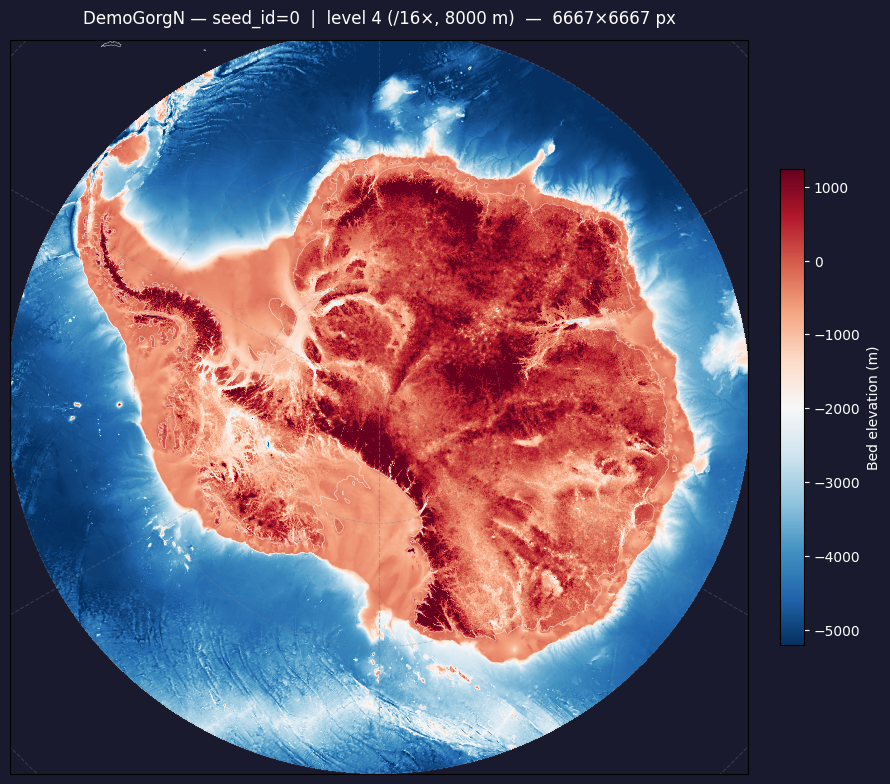

In [27]:
# Polar-stereographic static figure via cartopy (EPSG:3031)
import cartopy.crs as ccrs
import cartopy.feature as cfeature

da = pyramid_stored[OVERVIEW_LEVEL].ds["bed_elevation"].compute()
data = da.values
x_vals = da.x.values
y_vals = da.y.values

vmin = float(np.nanpercentile(data, 2))
vmax = float(np.nanpercentile(data, 98))

proj = ccrs.SouthPolarStereo()
data_crs = ccrs.epsg(3031)

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(1, 1, 1, projection=proj)
ax.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
ax.set_facecolor("#1a1a2e")
fig.patch.set_facecolor("#1a1a2e")

# Plot data in native EPSG:3031 coordinates
im = ax.pcolormesh(
    x_vals, y_vals, data,
    cmap="RdBu_r", vmin=vmin, vmax=vmax,
    transform=data_crs,
    shading="auto",
)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="white", alpha=0.6)
ax.gridlines(color="grey", alpha=0.3, linestyle="--")

cb = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cb.set_label("Bed elevation (m)", color="white")
cb.ax.yaxis.set_tick_params(color="white")
plt.setp(cb.ax.yaxis.get_ticklabels(), color="white")

factor = 2 ** int(OVERVIEW_LEVEL)
ax.set_title(
    f"DemoGorgN — seed_id={REALIZATION_INDEX}  |  level {OVERVIEW_LEVEL} (/{factor}×, "
    f"{int(res_m * factor)} m)  —  {data.shape[0]}×{data.shape[1]} px",
    color="white", pad=12,
)
plt.tight_layout()
plt.show()

## 8 — Interactive pyramid level browser (ipywidgets)

Browse variables and zoom levels without a tile server. Reads each level directly from the
local Icechunk pyramid store.

In [28]:
# Discover what's in the stored pyramid
available_levels = sorted(
    [
        p.path
        for p in pyramid_stored.subtree
        if pyramid_stored[p.path].ds.dims
    ],
    key=lambda s: int(s.lstrip("/")) if s.lstrip("/").isdigit() else 99,
)
available_vars = list(pyramid_stored[available_levels[0]].ds.data_vars)
print("Levels:", available_levels)
print("Variables:", available_vars)

Levels: ['/0', '/1', '/2', '/3', '/4']
Variables: ['spatial_ref', 'bed_elevation']


In [29]:
out = widgets.Output()

w_level = widgets.Dropdown(options=available_levels, value=available_levels[-1], description="Level:")
w_cmap  = widgets.Dropdown(
    options=["RdBu_r", "viridis", "plasma", "BrBG", "RdYlBu_r"],
    value="RdBu_r",
    description="Colormap:",
)
w_pct = widgets.IntRangeSlider(
    value=[2, 98], min=0, max=100, step=1,
    description="Clip %ile:", continuous_update=False, layout=widgets.Layout(width="400px")
)

controls = widgets.HBox([w_level, w_cmap, w_pct])


def update(_change=None):
    with out:
        out.clear_output(wait=True)
        level_path = w_level.value
        da = pyramid_stored[level_path].ds["bed_elevation"].compute()
        data = da.values
        valid = data[~np.isnan(data)]

        vlo, vhi = w_pct.value
        vmin = float(np.percentile(valid, vlo))
        vmax = float(np.percentile(valid, vhi))

        level_num = int(level_path.lstrip("/")) if level_path.lstrip("/").isdigit() else 0
        factor = 2 ** level_num
        resolution_m = int(res_m * factor)

        fig, (ax_img, ax_hist) = plt.subplots(1, 2, figsize=(14, 6))

        im = ax_img.imshow(data, cmap=w_cmap.value, vmin=vmin, vmax=vmax, origin="upper")
        ax_img.set_title(
            f"seed_id={REALIZATION_INDEX}  |  level {level_num}  (/{factor}×, {resolution_m} m)  "
            f"— {data.shape[0]}×{data.shape[1]} px"
        )
        ax_img.set_xlabel("x pixel")
        ax_img.set_ylabel("y pixel")
        plt.colorbar(im, ax=ax_img, label="m")

        ax_hist.hist(valid, bins=120, color="steelblue", alpha=0.8)
        ax_hist.axvline(vmin, color="red",   lw=1.5, linestyle="--", label=f"p{vlo}")
        ax_hist.axvline(vmax, color="orange", lw=1.5, linestyle="--", label=f"p{vhi}")
        ax_hist.set_title(f"Distribution — bed_elevation")
        ax_hist.set_xlabel("Value (m)")
        ax_hist.set_ylabel("Count")
        ax_hist.legend()

        plt.tight_layout()
        plt.show()

        print(
            f"Shape: {data.shape}   "
            f"Mean: {np.nanmean(data):.1f} m   "
            f"Std: {np.nanstd(data):.1f} m   "
            f"NaN: {np.isnan(data).mean() * 100:.1f}%"
        )


for w in [w_level, w_cmap, w_pct]:
    w.observe(update, names="value")

display(controls, out)
update()  # initial render

Output()

## 9 — Overview at all pyramid levels

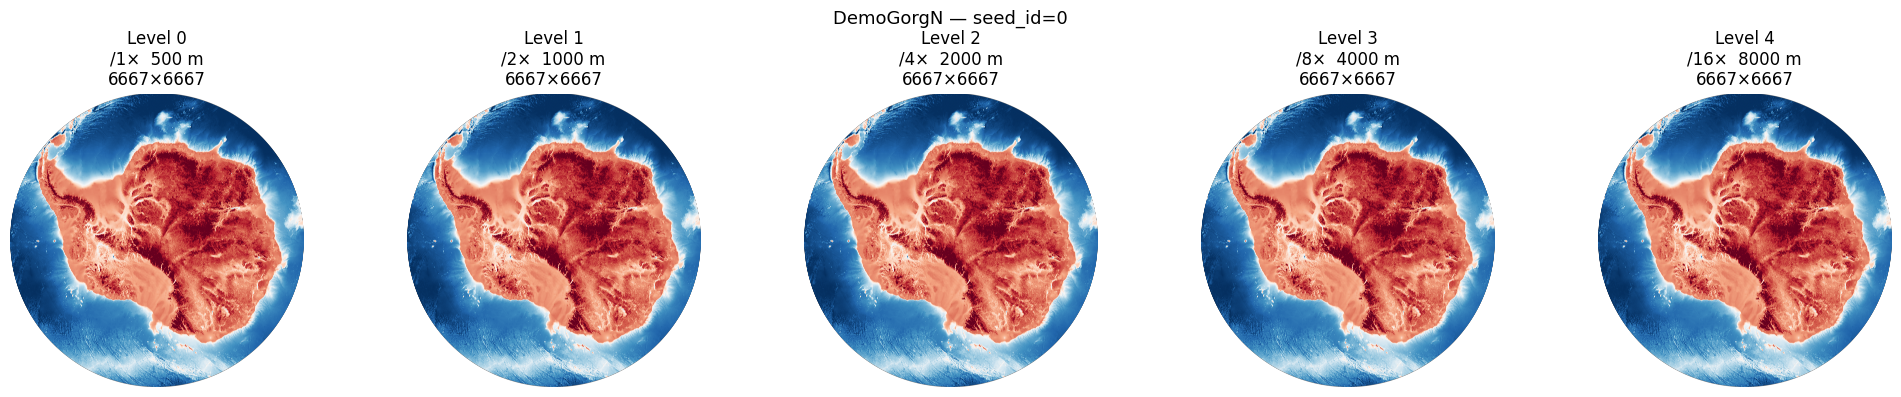

In [30]:
n_levels = len(available_levels)
fig, axes = plt.subplots(1, n_levels, figsize=(4 * n_levels, 4))

for ax, level_path in zip(axes, available_levels):
    da = pyramid_stored[level_path].ds["bed_elevation"].compute()
    data = da.values
    vmin = float(np.nanpercentile(data, 2))
    vmax = float(np.nanpercentile(data, 98))

    level_num = int(level_path.lstrip("/")) if level_path.lstrip("/").isdigit() else 0
    factor = 2 ** level_num

    ax.imshow(data, cmap="RdBu_r", vmin=vmin, vmax=vmax, origin="upper")
    ax.set_title(f"Level {level_num}\n/{factor}×  {int(res_m * factor)} m\n{data.shape[0]}×{data.shape[1]}")
    ax.axis("off")

plt.suptitle(f"DemoGorgN — seed_id={REALIZATION_INDEX}", fontsize=13)
plt.tight_layout()
plt.show()

## 10 — Snapshot history in Icechunk

Icechunk tracks every commit. Future pyramid updates (new realizations, new variables) can be
written as new snapshots and the old ones remain accessible.

In [31]:
for snap in pyr_repo.ancestry(branch="main"):
    print(f"  {snap.id[:12]}  {snap.written_at.isoformat()[:19]}  {snap.message!r}")

  DSPKZ4XVA2XA  2026-04-24T21:43:07  'Initial visualization pyramid'
  1CECHNKREP0F  2026-04-24T21:42:09  'Repository initialized'


## Next steps

| Goal | Recommended path |
|------|------------------|
| Push pyramid to S3 | Replace `local_filesystem_storage` with `s3_storage` in Section 5 |
| Dynamic tiles in production | Deploy `titiler-xarray` on AWS Lambda / ECS, point at S3 zarr |
| Polar-correct web map | Use `proj4leaflet` in Leaflet with EPSG:3031 tile scheme, or `deck.gl OrthographicView` |
| deck.gl-raster layer | Use `@deck.gl/geo-layers` `TileLayer` + `BitmapLayer`; tile URL from TiTiler |
| Visualize summary stats | Build pyramid from `ds.mean("seed_id")` / `ds.std("seed_id")` instead of a single realization |
| Update pyramid with new run | Open Icechunk in writable mode, overwrite specific levels, commit new snapshot |
